In [ ]:
import torch
import torch.nn as nn
import numpy as np
import solutions
import math

# Implement Softmax

Implement the **Softmax** function from scratch.

$$\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

### Signature
```python
def my_softmax(x: torch.Tensor, dim: int = -1) -> torch.Tensor:
    ...
```

### Rules
- Do **NOT** use `torch.softmax`, `F.softmax`, or `torch.nn.Softmax`
- Must be **numerically stable** (hint: subtract `max` before `exp`)

### Example
```
Input:  tensor([1., 2., 3.])
Output: tensor([0.0900, 0.2447, 0.6652])  # sums to 1.0
```

In [ ]:
def my_softmax(x: torch.Tensor, dim: int = -1) -> torch.Tensor:
    m = x.max(dim=-1, keepdim=True)[0]
    return torch.exp(x-m)/torch.sum(torch.exp(x-m), dim=-1, keepdim=True)

Tests

In [ ]:
logits = torch.tensor([2.0, 1.0, 0.1])

torch.allclose(my_softmax(logits), torch.softmax(logits, dim=0), atol=1e-07, equal_nan=True)

# Vanilla attention

Implement the core attention mechanism used in Transformers.

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

### Signature
```python
def scaled_dot_product_attention(
    Q: torch.Tensor,  # (batch, seq_q, d_k)
    K: torch.Tensor,  # (batch, seq_k, d_k)
    V: torch.Tensor,  # (batch, seq_k, d_v)
) -> torch.Tensor:   # (batch, seq_q, d_v)
    ...
```

In [ ]:
def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    return torch.matmul(torch.softmax(torch.matmul(Q, K.transpose(1,2))/torch.sqrt(d_k), dim=-1), V)

# Multi-head attention

Implement **Multi-Head Attention** from scratch — the core building block of the Transformer.

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) W^O$$
$$\text{head}_i = \text{Attention}(Q W_i^Q,\; K W_i^K,\; V W_i^V)$$

### Signature
```python
class MultiHeadAttention:
    def __init__(self, d_model: int, num_heads: int): ...
    def forward(self, Q, K, V) -> torch.Tensor: ...
```

### Requirements
- Use `nn.Linear(d_model, d_model)` for `self.W_q`, `self.W_k`, `self.W_v`, `self.W_o`
- `d_k = d_model // num_heads` per head
- `forward(Q, K, V)`: Q is `(B, seq_q, d_model)`, K/V are `(B, seq_k, d_model)`
- Must support **cross-attention** (`seq_q != seq_k`)
- Do **NOT** use `torch.nn.MultiheadAttention`
- You **may** use `torch.softmax` and `torch.matmul`

### Steps
1. Project: `q = self.W_q(Q)`, `k = self.W_k(K)`, `v = self.W_v(V)`
2. Reshape to `(B, num_heads, seq, d_k)`
3. Scaled dot-product attention per head
4. Concat heads → `(B, seq_q, d_model)`
5. Output projection: `self.W_o(concat)`

In [ ]:
class MultiHeadAttention:
    def __init__(self, d_model, num_heads):
        self.W_q = torch.nn.Linear(d_model, d_model)
        self.W_k = torch.nn.Linear(d_model, d_model)
        self.W_v = torch.nn.Linear(d_model, d_model)
        self.W_o = torch.nn.Linear(d_model, d_model)
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

    def forward(self, Q, K, V):
        q = self.W_q(Q) #[batch, n_seq, d_model]
        k = self.W_k(K)
        v = self.W_v(V)

        n_batch, q_n_seq, dim = Q.shape
        k_n_seq = K.shape[1]
        
        q = q.reshape(n_batch, q_n_seq, -1, self.d_k).transpose(1,2)
        k = k.reshape(n_batch, k_n_seq, -1, self.d_k).transpose(1,2)
        v = k.reshape(n_batch, k_n_seq, -1, self.d_k).transpose(1,2)

        attn = torch.matmul(q, k.transpose(2,3))/math.sqrt(self.d_k)
        attn = torch.softmax(attn, dim=-1)
        out = torch.matmul(attn, v)
        out = out.transpose(1,2).reshape(n_batch, q_n_seq, self.d_model)
        out = self.W_o(out)
        return out

# Grouped Query Attention (GQA)

Implement **Grouped Query Attention** — used in LLaMA 2, Mistral, etc. to reduce KV cache size.

Like MHA, but with **fewer KV heads** than Q heads. Each group of Q heads shares the same K/V head.

### Signature
```python
class GroupQueryAttention:
    def __init__(self, d_model: int, num_heads: int, num_kv_heads: int): ...
    def forward(self, x) -> torch.Tensor:  # self-attention
```

### Requirements
- `self.W_q`: `nn.Linear(d_model, d_model)` — full Q projection
- `self.W_k`: `nn.Linear(d_model, num_kv_heads * d_k)` — reduced K projection
- `self.W_v`: `nn.Linear(d_model, num_kv_heads * d_k)` — reduced V projection
- `self.W_o`: `nn.Linear(d_model, d_model)` — output projection
- `d_k = d_model // num_heads`
- Expand KV heads with `repeat_interleave` to match Q heads
- When `num_kv_heads == num_heads`, should behave like standard MHA

In [ ]:
class GroupQueryAttention:
    def __init__(self, d_model, num_heads, num_kv_heads):
        self.num_heads = num_heads
        self.num_kv_heads = num_kv_heads
        self.d_k = d_model // num_heads

        self.W_k = nn.Linear(d_model, num_kv_heads*self.d_k)
        self.W_v = nn.Linear(d_model, num_kv_heads*self.d_k)
        self.W_q = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x):
        k = self.W_k(x)
        v = self.W_v(x)
        q = self.W_q(x)

        batch, seq_k, _ = k.shape
        _, seq_q, d_model = q.shape
        
        k = k.reshape(batch, seq_k, self.num_kv_heads, self.d_k).transpose(1,2) 
        v = v.reshape(batch, seq_k, self.num_kv_heads, self.d_k).transpose(1,2)
        q = q.reshape(batch, seq_q, self.num_heads, self.d_k).transpose(1,2) 

        factor = self.num_heads//self.num_kv_heads
        k = torch.repeat_interleave(k, factor, dim=1)
        v = torch.repeat_interleave(v, factor, dim=1)

        a = torch.matmul(q,k.transpose(-1,-2))/math.sqrt(self.d_k)
        a = torch.softmax(a, dim=-1)
        o = torch.matmul(a, v)
        o = o.transpose(1,2).reshape(batch, seq_q, d_model)
        o = self.W_o(o)
        return o


# Flash Attention (Tiled)

Implement **tiled attention with online softmax** — the core idea behind Flash Attention.

### Signature
```python
def flash_attention(Q, K, V, block_size=32) -> Tensor:
    # Q, K, V: (B, S, D)
    # Returns: (B, S, D) — same as standard attention
```

### Key Insight
Instead of materializing the full S×S attention matrix, process in blocks:
1. For each Q-block, iterate over K/V blocks
2. Use **online softmax**: track running `max` and `sum`
3. Rescale accumulator when max changes: `acc *= exp(old_max - new_max)`
4. Final: `output = acc / row_sum`

Must give **identical** results to standard softmax attention.

In [ ]:
def flash_attention(Q, K, V, block_size=32):
    B, S, D = Q.shape
    output = torch.zeros_like(Q)
    for i in range(0, S, block_size):
        qi = Q[:, i:i+block_size]
        bs_q = qi.shape[1]
        row_max = torch.full((B, bs_q, 1), float('-inf'), device=Q.device)
        row_sum = torch.zeros(B, bs_q, 1, device=Q.device)
        acc = torch.zeros(B, bs_q, D, device=Q.device)
        for j in range(0, S, block_size):
            kj = K[:, j:j+block_size]
            vj = V[:, j:j+block_size]
            scores = torch.bmm(qi, kj.transpose(1, 2)) / math.sqrt(D)
            block_max = scores.max(dim=-1, keepdim=True).values
            new_max = torch.maximum(row_max, block_max)
            correction = torch.exp(row_max - new_max)
            exp_scores = torch.exp(scores - new_max)
            acc = acc * correction + torch.bmm(exp_scores, vj)
            row_sum = row_sum * correction + exp_scores.sum(dim=-1, keepdim=True)
            row_max = new_max
        output[:, i:i+block_size] = acc / row_sum
    return output

# GPT-2 Transformer Block

Implement a full **GPT-2 style Transformer block** — combining everything you've learned.

### Architecture (Pre-Norm)
```
x = x + causal_self_attention(ln1(x))
x = x + mlp(ln2(x))
```

### Signature
```python
class GPT2Block(nn.Module):
    def __init__(self, d_model: int, num_heads: int): ...
    def forward(self, x: torch.Tensor) -> torch.Tensor: ...
```

### Requirements
- Inherit from `nn.Module`
- `self.ln1`, `self.ln2`: `nn.LayerNorm(d_model)`
- `self.W_q`, `self.W_k`, `self.W_v`, `self.W_o`: `nn.Linear` for attention
- `self.mlp`: `nn.Sequential(Linear(d, 4d), GELU(), Linear(4d, d))`
- Attention must be **causal** (mask future positions)
- Pre-norm architecture (LayerNorm *before* attention and MLP)
- Residual connections around both attention and MLP

In [ ]:
class GPT2Block(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(d_model, 4*d_model),
                                 nn.GELU(),
                                 nn.Linear(4*d_model, d_model))
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_q = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.d_k = d_model//num_heads
        self.num_heads = num_heads
        
    def attn(self, x):
        batch, n_seq, d_model = x.shape
        K = self.W_k(x).reshape((batch, n_seq, self.num_heads, self.d_k)).transpose(1,2)
        V = self.W_v(x).reshape((batch, n_seq, self.num_heads, self.d_k)).transpose(1,2)
        Q = self.W_q(x).reshape((batch, n_seq, self.num_heads, self.d_k)).transpose(1,2)

        A = torch.matmul(Q, K.transpose(-1,-2))/math.sqrt(self.d_k)
        mask = torch.triu(torch.ones(n_seq, n_seq), diagonal=1).bool()
        A = torch.masked_fill(A, mask, float('-inf'))
        A = torch.softmax(A, dim=-1)
        O = torch.matmul(A, V)
        O = O.transpose(2,1).reshape((batch, n_seq, self.num_heads*self.d_k))
        return self.W_o(O)
        
    def forward(self, x):
        x = self.attn(self.ln1(x)) + x
        x = self.mlp(self.ln2(x)) + x
        return x        
        # pass  # Pre-norm + causal attention + MLP with residuals

# LoRA (Low-Rank Adaptation)

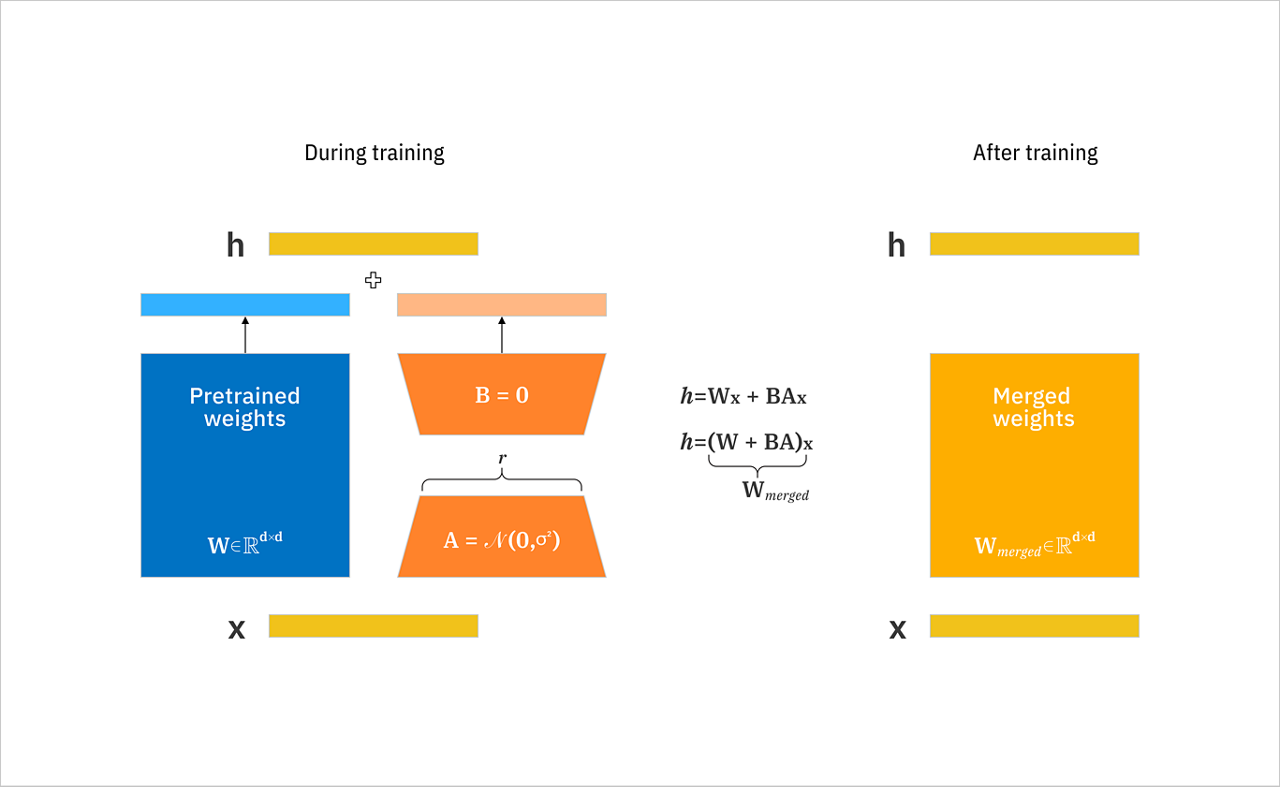

Implement **LoRA** — parameter-efficient fine-tuning for large models.

$$h = W_0 x + \frac{\alpha}{r} B A x$$

### Signature
```python
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, rank, alpha=1.0): ...
    def forward(self, x: Tensor) -> Tensor: ...
```

### Requirements
- `self.linear`: frozen `nn.Linear` (weight & bias `requires_grad=False`)
- `self.lora_A`: `nn.Parameter(rank, in_features)` — random init
- `self.lora_B`: `nn.Parameter(out_features, rank)` — **zero** init
- Scaling: `alpha / rank`

In [ ]:
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, rank, alpha=1.0):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.linear.weight.requires_grad_(False)
        self.linear.bias.requires_grad_(False)
        self.lora_A = nn.Parameter(torch.randn(rank, in_features) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))
        self.scaling = alpha / rank

    def forward(self, x):
        return self.linear(x) + (x @ self.lora_A.T @ self.lora_B.T) * self.scaling

# Mixture of Experts (MoE)

Implement a **Mixture of Experts** layer (Mixtral / Switch Transformer style).

### Signature
```python
class MixtureOfExperts(nn.Module):
    def __init__(self, d_model, d_ff, num_experts, top_k=2): ...
    def forward(self, x: Tensor) -> Tensor:
        # x: (B, S, D) -> (B, S, D)
```

### Architecture
- `self.router`: `nn.Linear(d_model, num_experts)` — gating network
- `self.experts`: `nn.ModuleList` of MLPs `(Linear→ReLU→Linear)`
- For each token: select top-k experts, compute weighted sum of their outputs

In [ ]:
class MixtureOfExperts(nn.Module):
    def __init__(self, d_model, d_ff, num_experts, top_k=2):
        super().__init__()
        self.top_k = top_k
        self.router = nn.Linear(d_model, num_experts)
        self.experts = nn.ModuleList([
            nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
            for _ in range(num_experts)
        ])

    def forward(self, x):
        orig_shape = x.shape
        if x.dim() == 3:
            B, S, D = x.shape
            x_flat = x.reshape(-1, D)
        else:
            x_flat = x
        logits = self.router(x_flat)
        top_vals, top_idx = logits.topk(self.top_k, dim=-1)
        weights = torch.softmax(top_vals, dim=-1)
        output = torch.zeros_like(x_flat)
        for k in range(self.top_k):
            for e in range(len(self.experts)):
                mask = (top_idx[:, k] == e)
                if mask.any():
                    output[mask] += weights[mask, k:k+1] * self.experts[e](x_flat[mask])
        return output.reshape(orig_shape)

# KV Cache Attention

Implement **multi-head attention with KV caching** for efficient autoregressive generation.

During LLM inference, recomputing all key/value projections at every step is wasteful.
A **KV cache** stores previously computed K and V tensors so only the new token(s) need projection.

### Signature
```python
class KVCacheAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int): ...
    def forward(self, x: torch.Tensor, cache=None) -> tuple[torch.Tensor, tuple]:
        # x: (B, S_new, D) — new tokens
        # cache: None or (K_past, V_past) each (B, num_heads, S_past, d_k)
        # Returns: (output, (K_all, V_all))
```

### Requirements
- Inherit from `nn.Module`
- `self.W_q`, `self.W_k`, `self.W_v`, `self.W_o`: `nn.Linear` projections
- When `cache=None` (prefill): apply **causal mask**, return all K/V as cache
- When `cache` provided (decode): concat new K/V with cached, no causal mask needed for single-token decode
- Incremental decode must produce **identical** results to full forward pass

### Key Idea
```
Prefill:  [t0 t1 t2 t3] → full causal attention → cache = (K_{0:3}, V_{0:3})
Decode:   [t4]           → Q=t4, K/V=cache+t4  → cache = (K_{0:4}, V_{0:4})
Decode:   [t5]           → Q=t5, K/V=cache+t5  → cache = (K_{0:5}, V_{0:5})
```

In [ ]:
class KVCacheAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x, cache=None):
        B, S_new, _ = x.shape

        q = self.W_q(x).view(B, S_new, self.num_heads, self.d_k).transpose(1, 2)
        k = self.W_k(x).view(B, S_new, self.num_heads, self.d_k).transpose(1, 2)
        v = self.W_v(x).view(B, S_new, self.num_heads, self.d_k).transpose(1, 2)

        if cache is not None:
            k = torch.cat([cache[0], k], dim=2)
            v = torch.cat([cache[1], v], dim=2)

        new_cache = (k, v)
        S_total = k.shape[2]

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)

        if S_new > 1:
            # Causal mask for prefill: each query position can only attend to
            # positions up to itself in the full sequence
            S_past = S_total - S_new
            mask = torch.triu(
                torch.ones(S_new, S_total, device=x.device, dtype=torch.bool),
                diagonal=S_past + 1,
            )
            scores = scores.masked_fill(mask, float('-inf'))

        weights = torch.softmax(scores, dim=-1)
        attn = torch.matmul(weights, v)
        out = self.W_o(attn.transpose(1, 2).contiguous().view(B, S_new, -1))
        return out, new_cache